<a href="https://colab.research.google.com/github/diolenomatias-ops/metrobot-fmu/blob/main/MetroBot_SP_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MetrôBot SP 2.0 (Linhas 1, 2 e 3)

**Integrantes do grupo:**
- Bruna Karlla Fernandes Marques RA: 2025115639
- Dioleno Matias Dos Santos RA: 2893378
- Janaina Maria Abreu da Silva RA: 2780529

In [ ]:
# ===== Configuração geral =====
import os
import json
import itertools
import heapq
from collections import deque

# "offline" (padrão, não precisa de internet/chave) | "groq" | "ollama"
PROVEDOR = "offline"

# A chave NUNCA fica no código: lemos de variável de ambiente.
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")  # pode ficar None — está tudo bem

# Bibliotecas opcionais (o notebook não pode quebrar se alguma não estiver instalada)
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
    TEM_WIDGETS = True
except Exception:
    TEM_WIDGETS = False
    print("⚠️ ipywidgets não disponível — o painel interativo (R5) não vai renderizar, mas todo o resto funciona.")

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    TEM_MATPLOTLIB = True
except Exception:
    TEM_MATPLOTLIB = False
    print("⚠️ matplotlib não disponível — os desenhos das linhas não vão renderizar.")

try:
    import networkx as nx
    TEM_NETWORKX = True
except Exception:
    TEM_NETWORKX = False

try:
    import requests
    TEM_REQUESTS = True
except Exception:
    TEM_REQUESTS = False

print("Provedor de LLM ativo:", PROVEDOR)
print("ipywidgets:", TEM_WIDGETS, "| matplotlib:", TEM_MATPLOTLIB, "| networkx:", TEM_NETWORKX)


Provedor de LLM ativo: offline
ipywidgets: True | matplotlib: True | networkx: True


In [ ]:
pip install pypdf

In [ ]:
import pypdf

def extract_text_from_pdf(pdf_path):
    text = ''
    try:
        with open(pdf_path, 'rb') as f:
            reader = pypdf.PdfReader(f)
            for page_num in range(len(reader.pages)):
                text += reader.pages[page_num].extract_text()
    except Exception as e:
        text = f"Error reading PDF: {e}"
    return text

pdf_content = extract_text_from_pdf('/content/fmu-desafgio.pdf')
print(pdf_content[:2000]) # Print first 2000 characters to avoid overwhelming output

 Essa combinação "LLM + lógica simbólica + algoritmos clássicos" é chamada de IA neuro-simbólica. O LLM dá ﬂexibilidade; a
lógica e a busca dão garantias.
Onde isso aparece de verdade 
Apps de mobilidade (Google Maps, Moovit, Citymapper): usam variações de busca em grafos (como Dijkstra e A*, que são "primas"
da BFS com custos) em redes com milhares de paradas.
Regras de negócio auditáveis: bancos, seguradoras e o ﬁsco usam motores de regras justamente porque precisam explicar cada
decisão — algo que um LLM sozinho não garante.
Assistentes com linguagem natural: o padrão "LLM interpreta → sistema conﬁável executa → LLM explica" está em chatbots de
atendimento, assistentes de viagem e agentes de codiﬁcação.
Agentes de codiﬁcação: exploram um espaço de estados (o repositório), com ações (edições) e uma heurística (os testes passam?)
— exatamente como a nossa busca.
 Debate em sala
Dividam a turma em dois lados e discutam:
"Por que não pedir a rota direto ao Llama?"1.
Lado A: "É mais simp

## 📋 R1 — Dados das linhas (grafo das 3 linhas)

Usamos exatamente os nomes de estações do enunciado.

In [ ]:
LINHAS = {
    "Linha 1-Azul": [
        "Tucuruvi", "Parada Inglesa", "Jardim São Paulo", "Santana",
        "Carandiru", "Portuguesa-Tietê", "Armênia", "Tiradentes", "Luz",
        "São Bento", "Sé", "Japão-Liberdade", "São Joaquim", "Vergueiro",
        "Paraíso", "Ana Rosa", "Vila Mariana", "Santa Cruz",
        "Praça da Árvore", "Saúde", "São Judas", "Conceição", "Jabaquara",
    ],
    "Linha 2-Verde": [
        "Vila Madalena", "Sumaré", "Clínicas", "Consolação", "Trianon-Masp",
        "Brigadeiro", "Paraíso", "Ana Rosa", "Chácara Klabin",
        "Santos-Imigrantes", "Alto do Ipiranga", "Sacomã", "Tamanduateí",
        "Vila Prudente",
    ],
    "Linha 3-Vermelha": [
        "Palmeiras-Barra Funda", "Marechal Deodoro", "Santa Cecília",
        "República", "Anhangabaú", "Sé", "Pedro II", "Brás",
        "Bresser-Mooca", "Belém", "Tatuapé", "Carrão", "Penha",
        "Vila Matilde", "Guilhermina-Esperança", "Patriarca-Vila Ré",
        "Artur Alvim", "Corinthians-Itaquera",
    ],
}

CORES = {"Linha 1-Azul": "#1e88e5", "Linha 2-Verde": "#2e7d32",
         "Linha 3-Vermelha": "#d32f2f"}


## 🧩 R1 — `construir_grafo_multilinhas`

- Cada **estação é um nó único**, mesmo pertencendo a duas linhas (ex: "Sé").
- Guardamos, para cada trecho `(a, b)`, **o conjunto de linhas** que passam por ele
  (`linhas_do_trecho[("Paraíso","Ana Rosa")] = {"Linha 1-Azul","Linha 2-Verde"}`).
- Nenhum vizinho é duplicado na lista de adjacência.

In [ ]:
def construir_grafo_multilinhas(linhas):
    """Retorna (grafo, linhas_do_trecho).
    grafo: {estacao: [vizinhas sem repetição]}
    linhas_do_trecho: {(a, b): {nomes das linhas}} — guarda (a,b) e (b,a)
    """
    grafo = {}
    linhas_do_trecho = {}
    for nome_linha, estacoes in linhas.items():
        for i in range(len(estacoes) - 1):
            a, b = estacoes[i], estacoes[i + 1]
            # TODO 1: garantir que a e b existem no grafo
            grafo.setdefault(a, [])
            grafo.setdefault(b, [])
            # TODO 2: adicionar b como vizinha de a (e vice-versa) SEM duplicar
            if b not in grafo[a]:
                grafo[a].append(b)
            if a not in grafo[b]:
                grafo[b].append(a)
            # TODO 3: registrar nome_linha em linhas_do_trecho[(a, b)] e [(b, a)]
            linhas_do_trecho.setdefault((a, b), set()).add(nome_linha)
            linhas_do_trecho.setdefault((b, a), set()).add(nome_linha)
    return grafo, linhas_do_trecho


GRAFO, LINHAS_DO_TRECHO = construir_grafo_multilinhas(LINHAS)

print(f"Total de estações (nós) no grafo: {len(GRAFO)}  (esperado: 52)")
print("Exemplo — trechos de 'Sé':", GRAFO["Sé"])
print("Exemplo — linhas do trecho Paraíso↔Ana Rosa:", LINHAS_DO_TRECHO[("Paraíso", "Ana Rosa")])
assert len(GRAFO) == 52, "O grafo deveria ter exatamente 52 estações únicas!"


Total de estações (nós) no grafo: 52  (esperado: 52)
Exemplo — trechos de 'Sé': ['São Bento', 'Japão-Liberdade', 'Anhangabaú', 'Pedro II']
Exemplo — linhas do trecho Paraíso↔Ana Rosa: {'Linha 2-Verde', 'Linha 1-Azul'}


## 🔎 R2 — Busca (BFS e DFS) respeitando estações bloqueadas

Ambas retornam `(caminho, visitadas)` para podermos comparar o **esforço** de cada algoritmo
(quantas estações cada um "olhou" até achar a rota).

In [ ]:
def bfs(grafo, origem, destino, bloqueadas=None):
    """Busca em largura. Retorna (caminho, visitadas) ou (None, visitadas)."""
    bloqueadas = bloqueadas or set()
    if origem in bloqueadas or destino in bloqueadas:
        return None, []
    visitadas = [origem]
    vistos = {origem}
    fila = deque([[origem]])
    while fila:
        caminho = fila.popleft()
        atual = caminho[-1]
        if atual == destino:
            return caminho, visitadas
        for viz in grafo.get(atual, []):
            if viz in bloqueadas or viz in vistos:
                continue
            vistos.add(viz)
            visitadas.append(viz)
            fila.append(caminho + [viz])
    return None, visitadas


def dfs(grafo, origem, destino, bloqueadas=None):
    """Busca em profundidade (iterativa, com pilha). Retorna (caminho, visitadas)."""
    bloqueadas = bloqueadas or set()
    if origem in bloqueadas or destino in bloqueadas:
        return None, []
    visitadas = [origem]
    vistos = {origem}
    pilha = [[origem]]
    while pilha:
        caminho = pilha.pop()
        atual = caminho[-1]
        if atual == destino:
            return caminho, visitadas
        for viz in grafo.get(atual, []):
            if viz in bloqueadas or viz in vistos:
                continue
            vistos.add(viz)
            visitadas.append(viz)
            pilha.append(caminho + [viz])
    return None, visitadas


def contar_baldeacoes(caminho, linhas_do_trecho):
    """Retorna (quantidade, lista de (estacao, linha_nova)).
    Percorre os trechos do caminho, mantendo a 'linha atual'; se a linha atual
    não serve mais o próximo trecho, é uma baldeação. Para cada trecho,
    preferimos continuar na mesma linha se ela servir (evita baldeação 'falsa'
    em trechos como Paraíso–Ana Rosa, que existem em duas linhas ao mesmo tempo).
    """
    if not caminho or len(caminho) < 2:
        return 0, []
    baldeacoes = []
    linha_atual = None
    for i in range(len(caminho) - 1):
        a, b = caminho[i], caminho[i + 1]
        linhas_trecho = linhas_do_trecho.get((a, b), set())
        if linha_atual is not None and linha_atual in linhas_trecho:
            continue  # a linha atual ainda serve esse trecho: sem baldeação
        nova_linha = sorted(linhas_trecho)[0] if linhas_trecho else None
        if linha_atual is not None:
            baldeacoes.append((a, nova_linha))
        linha_atual = nova_linha
    return len(baldeacoes), baldeacoes


# Teste rápido
c, v = bfs(GRAFO, "Tucuruvi", "Corinthians-Itaquera")
print("BFS Tucuruvi → Corinthians-Itaquera:", len(c) - 1, "paradas |", len(v), "estações visitadas")
print("Baldeações:", contar_baldeacoes(c, LINHAS_DO_TRECHO))


BFS Tucuruvi → Corinthians-Itaquera: 22 paradas | 52 estações visitadas
Baldeações: (1, [('Sé', 'Linha 3-Vermelha')])


## 📚 R3 — Base de conhecimento e lógica

### Locais conhecidos (mínimo 3 por linha / 9 no total)

In [ ]:
LOCAIS_CONHECIDOS = {
    "Linha 1-Azul": [
        ("Estação da Luz / Museu da Língua Portuguesa", "Luz"),
        ("Catedral da Sé", "Sé"),
        ("Parque Ibirapuera (portão mais próximo)", "Vila Mariana"),
    ],
    "Linha 2-Verde": [
        ("MASP", "Trianon-Masp"),
        ("Hospital das Clínicas (USP)", "Clínicas"),
        ("Theatro Municipal / região da Consolação", "Consolação"),
    ],
    "Linha 3-Vermelha": [
        ("Neo Química Arena (Corinthians)", "Corinthians-Itaquera"),
        ("Memorial da América Latina", "Marechal Deodoro"),
        ("Mosteiro de São Bento (região central)", "Sé"),
    ],
}

total_locais = sum(len(v) for v in LOCAIS_CONHECIDOS.values())
print(f"Total de locais cadastrados: {total_locais} (mínimo exigido: 9)")
assert total_locais >= 9
assert all(len(v) >= 3 for v in LOCAIS_CONHECIDOS.values())

# índice reverso: nome do local -> estação mais próxima (usado pelo intérprete)
LOCAL_PARA_ESTACAO = {nome: estacao for lista in LOCAIS_CONHECIDOS.values() for nome, estacao in lista}
TODAS_ESTACOES = sorted(GRAFO.keys())


Total de locais cadastrados: 9 (mínimo exigido: 9)


### Motor de inferência — encadeamento para frente (forward chaining)

Fatos são tuplas simples, ex.: `("pertence", "Sé", "Linha 1-Azul")`, `("bloqueada", "Paraíso")`.

**Regras R1–R5 (adaptadas da aula):**
- **R1** — `bloqueada(e) → indisponivel(e)`
- **R2** — `precisa_acessibilidade ∧ elevador_manutencao(e) → inacessivel(e)`
- **R3** — `integracao(e) ∧ indisponivel(e) → necessita_desvio(e)`
- **R4** — `linha_paralisada(l) ∧ pertence(e,l) → indisponivel(e)` *(liga com o Bônus "linha paralisada")*
- **R5** — `horario_pico ∧ integracao(e) → estacao_critica(e)` *(risco de lotação)*

**R6 (obrigatória, integração):**
`∀e ∀l1 ∀l2 (pertence(e,l1) ∧ pertence(e,l2) ∧ l1≠l2 → integracao(e))`
— as integrações (Sé, Paraíso, Ana Rosa) são **deduzidas pelo motor**, nunca digitadas à mão.

**R7 (criada pelo grupo):** estação de integração com elevador em manutenção precisa de reparo prioritário.

`∀e (integracao(e) ∧ elevador_manutencao(e) → prioridade_reparo(e))`

*Justificativa: uma integração concentra o fluxo de duas linhas — um elevador quebrado ali afeta
muito mais passageiros com deficiência ou mobilidade reduzida do que numa estação comum, então deve
ser corrigido com prioridade.*

In [ ]:
def fatos_base(linhas, estacoes_bloqueadas=None, elevadores_manutencao=None,
                precisa_acessibilidade=False, horario_pico=False, linhas_paralisadas=None):
    """R3/R5: gera os fatos pertence(estacao, linha) para TODAS as estações + fatos do cenário."""
    estacoes_bloqueadas = estacoes_bloqueadas or set()
    elevadores_manutencao = elevadores_manutencao or set()
    linhas_paralisadas = linhas_paralisadas or set()
    fatos = set()
    for nome_linha, estacoes in linhas.items():
        for e in estacoes:
            fatos.add(("pertence", e, nome_linha))
    for e in estacoes_bloqueadas:
        fatos.add(("bloqueada", e))
    for e in elevadores_manutencao:
        fatos.add(("elevador_manutencao", e))
    if precisa_acessibilidade:
        fatos.add(("precisa_acessibilidade",))
    if horario_pico:
        fatos.add(("horario_pico",))
    for l in linhas_paralisadas:
        fatos.add(("linha_paralisada", l))
    return fatos


def _regra_R1_bloqueio(fatos, linhas):
    novos = []
    for f in fatos:
        if f[0] == "bloqueada":
            e = f[1]
            novo = ("indisponivel", e)
            if novo not in fatos:
                novos.append((novo, f"R1: '{e}' está bloqueada ⇒ indisponível"))
    return novos


def _regra_R2_acessibilidade(fatos, linhas):
    novos = []
    if ("precisa_acessibilidade",) not in fatos:
        return novos
    for f in fatos:
        if f[0] == "elevador_manutencao":
            e = f[1]
            novo = ("inacessivel", e)
            if novo not in fatos:
                novos.append((novo, f"R2: passageiro precisa de acessibilidade ∧ elevador de '{e}' em manutenção ⇒ '{e}' inacessível"))
    return novos


def _regra_R6_integracao(fatos, linhas):
    """R6 obrigatória: ∀e ∀l1 ∀l2 (pertence(e,l1) ∧ pertence(e,l2) ∧ l1≠l2 → integracao(e))"""
    novos = []
    by_estacao = {}
    for f in fatos:
        if f[0] == "pertence":
            by_estacao.setdefault(f[1], set()).add(f[2])
    for e, ls in by_estacao.items():
        if len(ls) > 1:
            novo = ("integracao", e)
            if novo not in fatos:
                l1, l2 = sorted(ls)[0], sorted(ls)[1]
                novos.append((novo, f"R6: '{e}' pertence a '{l1}' e '{l2}' (l1≠l2) ⇒ '{e}' é integração"))
    return novos


def _regra_R3_desvio_necessario(fatos, linhas):
    novos = []
    integracoes = {f[1] for f in fatos if f[0] == "integracao"}
    indisponiveis = {f[1] for f in fatos if f[0] == "indisponivel"}
    for e in integracoes & indisponiveis:
        novo = ("necessita_desvio", e)
        if novo not in fatos:
            novos.append((novo, f"R3: '{e}' é integração ∧ está indisponível ⇒ necessita desvio"))
    return novos


def _regra_R4_linha_paralisada(fatos, linhas):
    novos = []
    paralisadas = {f[1] for f in fatos if f[0] == "linha_paralisada"}
    for l in paralisadas:
        for e in linhas.get(l, []):
            novo = ("indisponivel", e)
            if novo not in fatos:
                novos.append((novo, f"R4: linha '{l}' paralisada ⇒ '{e}' indisponível"))
    return novos


def _regra_R5_estacao_critica(fatos, linhas):
    novos = []
    if ("horario_pico",) not in fatos:
        return novos
    integracoes = {f[1] for f in fatos if f[0] == "integracao"}
    for e in integracoes:
        novo = ("estacao_critica", e)
        if novo not in fatos:
            novos.append((novo, f"R5: horário de pico ∧ '{e}' é integração ⇒ '{e}' é crítica (risco de lotação)"))
    return novos


def _regra_R7_prioridade_reparo(fatos, linhas):
    """R7 (do grupo): ∀e (integracao(e) ∧ elevador_manutencao(e) → prioridade_reparo(e))"""
    novos = []
    integracoes = {f[1] for f in fatos if f[0] == "integracao"}
    manutencao = {f[1] for f in fatos if f[0] == "elevador_manutencao"}
    for e in integracoes & manutencao:
        novo = ("prioridade_reparo", e)
        if novo not in fatos:
            novos.append((novo, f"R7: '{e}' é integração ∧ tem elevador em manutenção ⇒ prioridade de reparo"))
    return novos


REGRAS = [
    _regra_R1_bloqueio, _regra_R2_acessibilidade, _regra_R6_integracao,
    _regra_R3_desvio_necessario, _regra_R4_linha_paralisada,
    _regra_R5_estacao_critica, _regra_R7_prioridade_reparo,
]


def encadear_para_frente(fatos_iniciais, linhas):
    """Motor de inferência genérico: aplica as regras até não haver mais fatos novos (ponto fixo)."""
    fatos = set(fatos_iniciais)
    disparadas = []
    mudou = True
    while mudou:
        mudou = False
        for regra in REGRAS:
            for novo, justificativa in regra(fatos, linhas):
                if novo not in fatos:
                    fatos.add(novo)
                    disparadas.append(justificativa)
                    mudou = True
    return fatos, disparadas


# Demonstração
_fatos0 = fatos_base(LINHAS, estacoes_bloqueadas={"Paraíso"}, elevadores_manutencao={"Sé"},
                      precisa_acessibilidade=True, horario_pico=True)
_fatos_final, _disparadas = encadear_para_frente(_fatos0, LINHAS)
_integracoes = sorted({f[1] for f in _fatos_final if f[0] == "integracao"})
print("Integrações deduzidas automaticamente pelo motor:", _integracoes)
assert _integracoes == ["Ana Rosa", "Paraíso", "Sé"], "R6 deveria deduzir Sé, Paraíso e Ana Rosa!"
print("\nRegras disparadas neste cenário de exemplo:")
for d in _disparadas:
    print(" •", d)


Integrações deduzidas automaticamente pelo motor: ['Ana Rosa', 'Paraíso', 'Sé']

Regras disparadas neste cenário de exemplo:
 • R1: 'Paraíso' está bloqueada ⇒ indisponível
 • R2: passageiro precisa de acessibilidade ∧ elevador de 'Sé' em manutenção ⇒ 'Sé' inacessível
 • R6: 'Ana Rosa' pertence a 'Linha 1-Azul' e 'Linha 2-Verde' (l1≠l2) ⇒ 'Ana Rosa' é integração
 • R6: 'Sé' pertence a 'Linha 1-Azul' e 'Linha 3-Vermelha' (l1≠l2) ⇒ 'Sé' é integração
 • R6: 'Paraíso' pertence a 'Linha 1-Azul' e 'Linha 2-Verde' (l1≠l2) ⇒ 'Paraíso' é integração
 • R3: 'Paraíso' é integração ∧ está indisponível ⇒ necessita desvio
 • R5: horário de pico ∧ 'Paraíso' é integração ⇒ 'Paraíso' é crítica (risco de lotação)
 • R5: horário de pico ∧ 'Ana Rosa' é integração ⇒ 'Ana Rosa' é crítica (risco de lotação)
 • R5: horário de pico ∧ 'Sé' é integração ⇒ 'Sé' é crítica (risco de lotação)
 • R7: 'Sé' é integração ∧ tem elevador em manutenção ⇒ prioridade de reparo


### Tabela-verdade (lógica proposicional)

Reaproveitando a fórmula da catraca vista em aula — `P ∧ (¬Q ∨ R)` — aplicada ao domínio do MetrôBot:

- **P** = a estação pertence à rota planejada
- **Q** = a estação está bloqueada
- **R** = existe um desvio disponível para essa estação

`estacao_utilizavel = P ∧ (¬Q ∨ R)` → "a estação faz parte da rota **e** (não está bloqueada **ou**
existe desvio)".

In [ ]:
def gerar_tabela_verdade(variaveis, formula):
    """Gera a tabela-verdade (lista de (valores, resultado)) para uma fórmula proposicional."""
    linhas_tabela = []
    for valores in itertools.product([False, True], repeat=len(variaveis)):
        ctx = dict(zip(variaveis, valores))
        linhas_tabela.append((valores, formula(**ctx)))
    return linhas_tabela


def _formula_estacao_utilizavel(P, Q, R):
    return P and ((not Q) or R)


_variaveis = ["P (pertence_a_rota)", "Q (bloqueada)", "R (tem_desvio)"]
_tabela = gerar_tabela_verdade(["P", "Q", "R"], _formula_estacao_utilizavel)

print(f"{'P':<6}{'Q':<6}{'R':<6} | estacao_utilizavel = P ∧ (¬Q ∨ R)")
print("-" * 45)
for valores, resultado in _tabela:
    p, q, r = valores
    print(f"{str(p):<6}{str(q):<6}{str(r):<6} | {resultado}")

assert len(_tabela) == 8


P     Q     R      | estacao_utilizavel = P ∧ (¬Q ∨ R)
---------------------------------------------
False False False  | False
False False True   | False
False True  False  | False
False True  True   | False
True  False False  | True
True  False True   | True
True  True  False  | False
True  True  True   | True


## 🤖 R4 — Interpretação de linguagem natural (Llama via Groq/Ollama) + Narrador

- O **LLM nunca decide a rota** — ele só (1) transforma texto livre em um pedido estruturado (JSON)
  e (2) narra, em português, a rota que o algoritmo já calculou. `"O LLM conversa, o algoritmo decide."`
- Em `PROVEDOR = "offline"` (ou se a chamada de API falhar por qualquer motivo), tudo continua
  funcionando com um **intérprete por regras/palavras-chave** e um **narrador por template**.
- Toda saída do intérprete é **validada** contra a lista real de estações/locais antes de ser usada.

In [ ]:
PROMPT_INTERPRETE = f"""Você é o intérprete do MetrôBot SP. Dado um pedido em português sobre uma
viagem de metrô, devolva SOMENTE um JSON (sem markdown, sem texto extra) com os campos:
{{
  "origem": "<nome exato de uma estação da lista>",
  "destino": "<nome exato de uma estação da lista>",
  "acessibilidade": <true|false>,
  "algoritmo": "<bfs|dfs>"
}}
Estações válidas (use o nome EXATO, sem inventar): {TODAS_ESTACOES}
Locais conhecidos e a estação mais próxima: {LOCAL_PARA_ESTACAO}
Se não conseguir identificar origem ou destino com certeza, use null nesse campo."""


def _chamar_llm_groq(prompt_sistema, mensagem_usuario):
    if not (TEM_REQUESTS and GROQ_API_KEY):
        raise RuntimeError("Groq indisponível (sem requests ou sem GROQ_API_KEY)")
    resp = requests.post(
        "https://api.groq.com/openai/v1/chat/completions",
        headers={"Authorization": f"Bearer {GROQ_API_KEY}", "Content-Type": "application/json"},
        json={
            "model": "llama-3.3-70b-versatile",
            "messages": [
                {"role": "system", "content": prompt_sistema},
                {"role": "user", "content": mensagem_usuario},
            ],
            "temperature": 0.2,
        },
        timeout=8,
    )
    resp.raise_for_status()
    return resp.json()["choices"][0]["message"]["content"]


def _chamar_llm_ollama(prompt_sistema, mensagem_usuario):
    if not TEM_REQUESTS:
        raise RuntimeError("Ollama indisponível (sem requests)")
    resp = requests.post(
        "http://localhost:11434/api/generate",
        json={"model": "llama3", "prompt": f"{prompt_sistema}\n\n{mensagem_usuario}", "stream": False},
        timeout=8,
    )
    resp.raise_for_status()
    return resp.json()["response"]


def chamar_llm(prompt_sistema, mensagem_usuario):
    """Tenta o provedor configurado; qualquer falha cai para None (modo offline assume)."""
    try:
        if PROVEDOR == "groq":
            return _chamar_llm_groq(prompt_sistema, mensagem_usuario)
        if PROVEDOR == "ollama":
            return _chamar_llm_ollama(prompt_sistema, mensagem_usuario)
    except Exception as exc:
        print(f"⚠️ LLM indisponível ({exc}) — usando modo offline.")
    return None


def _encontrar_estacao_no_texto(texto, candidatas):
    """Interpretador offline: procura o nome de estação/local mais longo que aparece no texto."""
    texto_low = texto.lower()
    melhor = None
    for nome in candidatas:
        if nome.lower() in texto_low:
            if melhor is None or len(nome) > len(melhor):
                melhor = nome
    return melhor


def interpretar_pedido(texto):
    """R4 — Intérprete: texto → JSON validado. Nunca aceita estação fora da lista real."""
    resultado = {"origem": None, "destino": None, "acessibilidade": False, "algoritmo": "bfs"}

    resposta_llm = chamar_llm(PROMPT_INTERPRETE, texto)
    if resposta_llm:
        try:
            limpo = resposta_llm.strip().strip("`")
            if limpo.startswith("json"):
                limpo = limpo[4:]
            dado = json.loads(limpo)
            for campo in ("origem", "destino"):
                valor = dado.get(campo)
                if valor in TODAS_ESTACOES:
                    resultado[campo] = valor
                elif valor in LOCAL_PARA_ESTACAO:
                    resultado[campo] = LOCAL_PARA_ESTACAO[valor]
                # se não validar, mantém None (nunca inventa estação)
            resultado["acessibilidade"] = bool(dado.get("acessibilidade", False))
            if dado.get("algoritmo") in ("bfs", "dfs"):
                resultado["algoritmo"] = dado["algoritmo"]
            return resultado
        except Exception:
            pass  # cai para o modo offline abaixo

    # ----- modo offline: heurística por palavras-chave -----
    candidatas = TODAS_ESTACOES + list(LOCAL_PARA_ESTACAO.keys())
    partes = texto.lower().split(" para ")
    if len(partes) == 2:
        origem_txt, destino_txt = partes
    else:
        origem_txt, destino_txt = texto, texto

    origem_encontrada = _encontrar_estacao_no_texto(origem_txt, candidatas)
    destino_encontrado = _encontrar_estacao_no_texto(destino_txt, candidatas)
    if origem_encontrada == destino_encontrado:
        # texto não distinguiu bem as duas partes: tenta achar 2 estações diferentes no texto todo
        achadas = [n for n in candidatas if n.lower() in texto.lower()]
        achadas = sorted(set(achadas), key=len, reverse=True)
        if len(achadas) >= 2:
            origem_encontrada, destino_encontrado = achadas[0], achadas[1]

    resultado["origem"] = LOCAL_PARA_ESTACAO.get(origem_encontrada, origem_encontrada)
    resultado["destino"] = LOCAL_PARA_ESTACAO.get(destino_encontrado, destino_encontrado)
    resultado["acessibilidade"] = any(p in texto.lower() for p in ["cadeirante", "acessibilidade", "acessível", "mobilidade reduzida"])
    resultado["algoritmo"] = "dfs" if "dfs" in texto.lower() else "bfs"
    return resultado


def narrar(origem, destino, caminho, baldeacoes_info, regras_disparadas, algoritmo):
    """R4 — Narrador: explica a rota já calculada, citando baldeações. Nunca inventa dados."""
    if caminho is None:
        template = (f"Não encontrei uma rota de {origem} até {destino} com as condições atuais "
                     f"(alguma estação necessária está bloqueada/indisponível).")
        resposta_llm = chamar_llm(
            "Você narra, em 1-2 frases em português, que NÃO existe rota disponível. "
            "Não invente motivos além dos fatos dados.",
            f"Origem: {origem}. Destino: {destino}. Sem rota encontrada.")
        return resposta_llm.strip() if resposta_llm else template

    paradas = len(caminho) - 1
    partes = [f"Rota de {origem} até {destino} usando {algoritmo.upper()}: {paradas} parada(s)."]
    if baldeacoes_info:
        for estacao, nova_linha in baldeacoes_info:
            partes.append(f"Na {estacao}, troque para a {nova_linha}.")
    else:
        partes.append("Sem baldeações — é tudo na mesma linha.")
    if regras_disparadas:
        partes.append(f"Regras do motor de inferência disparadas: {len(regras_disparadas)}.")
    template = " ".join(partes)

    if PROVEDOR != "offline":
        dados_factuais = {
            "origem": origem, "destino": destino, "paradas": paradas,
            "caminho": caminho, "baldeacoes": baldeacoes_info, "algoritmo": algoritmo,
        }
        resposta_llm = chamar_llm(
            "Você é o narrador do MetrôBot. Reescreva os FATOS abaixo em 2-3 frases naturais em "
            "português, citando claramente cada baldeação e onde trocar de linha. NÃO invente "
            "estações, linhas ou números que não estejam nos fatos.",
            json.dumps(dados_factuais, ensure_ascii=False))
        if resposta_llm:
            return resposta_llm.strip()
    return template


# Demonstração em modo offline
print(interpretar_pedido("Quero ir do MASP até o Corinthians-Itaquera, sou cadeirante"))


{'origem': 'Corinthians-Itaquera', 'destino': 'Trianon-Masp', 'acessibilidade': True, 'algoritmo': 'bfs'}


## 🎨 Desenho das 3 linhas (R5) + 🗺️ Bônus "Mapa de verdade"

Cada linha é desenhada em uma "trilha" horizontal própria, com as estações de integração alinhadas
verticalmente (Sé, Paraíso, Ana Rosa), usando as cores oficiais de `CORES`. A rota calculada é
destacada, as estações visitadas pela busca ficam marcadas e as bloqueadas aparecem com um X.

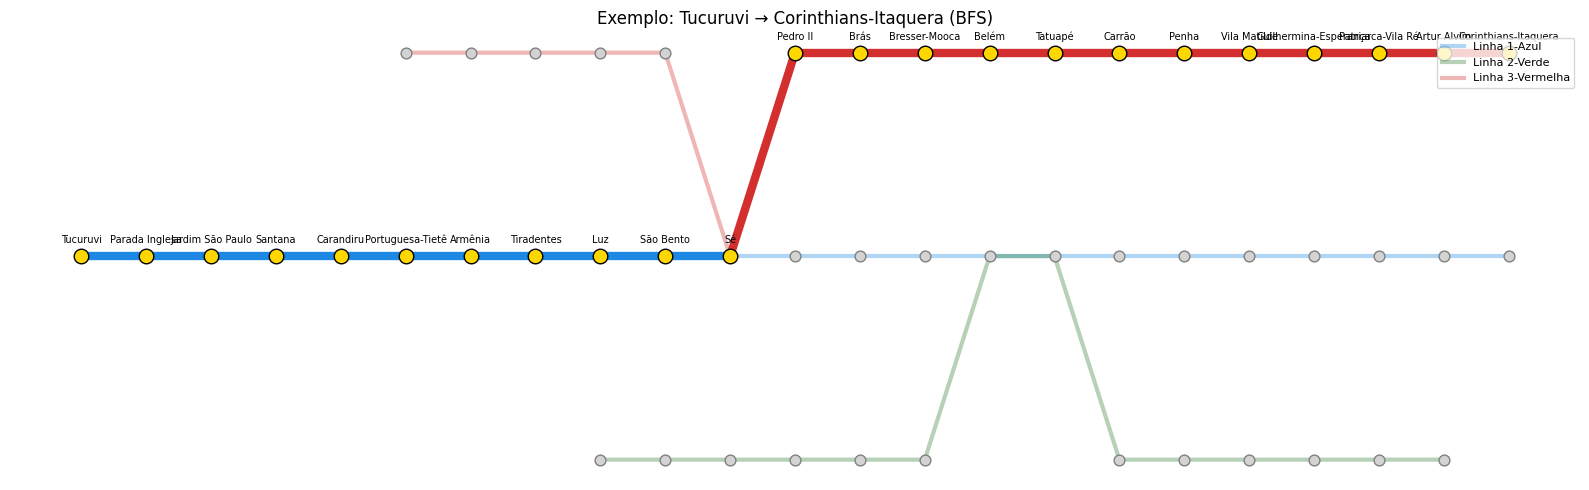

In [ ]:
_POSICOES = {}
for _i, _e in enumerate(LINHAS["Linha 1-Azul"]):
    _POSICOES.setdefault(_e, (_i * 1.0, 0))
_offset2 = {"Paraíso": None, "Ana Rosa": None}
_x_paraiso = _POSICOES["Paraíso"][0]
_x_anarosa = _POSICOES["Ana Rosa"][0]
_deslocamento2 = _x_paraiso - LINHAS["Linha 2-Verde"].index("Paraíso")
for _i, _e in enumerate(LINHAS["Linha 2-Verde"]):
    if _e not in _POSICOES:
        _POSICOES[_e] = (_i + _deslocamento2, -1.4)
_x_se = _POSICOES["Sé"][0]
_deslocamento3 = _x_se - LINHAS["Linha 3-Vermelha"].index("Sé")
for _i, _e in enumerate(LINHAS["Linha 3-Vermelha"]):
    if _e not in _POSICOES:
        _POSICOES[_e] = (_i + _deslocamento3, 1.4)


def desenhar_mapa(caminho=None, visitadas=None, bloqueadas=None, titulo="MetrôBot SP — Linhas 1, 2 e 3"):
    if not TEM_MATPLOTLIB:
        print("matplotlib indisponível — não é possível desenhar o mapa aqui.")
        return
    visitadas = set(visitadas or [])
    bloqueadas = set(bloqueadas or [])
    caminho = caminho or []
    caminho_set = set(caminho)
    caminho_arestas = set(zip(caminho, caminho[1:])) | set(zip(caminho[1:], caminho))

    fig, ax = plt.subplots(figsize=(16, 5))
    for nome_linha, estacoes in LINHAS.items():
        cor = CORES[nome_linha]
        xs = [_POSICOES[e][0] for e in estacoes]
        ys = [_POSICOES[e][1] for e in estacoes]
        ax.plot(xs, ys, "-", color=cor, linewidth=3, alpha=0.35, zorder=1, label=nome_linha)
        for i in range(len(estacoes) - 1):
            a, b = estacoes[i], estacoes[i + 1]
            if (a, b) in caminho_arestas:
                xa, ya = _POSICOES[a]
                xb, yb = _POSICOES[b]
                ax.plot([xa, xb], [ya, yb], "-", color=cor, linewidth=6, zorder=2)

    for e, (x, y) in _POSICOES.items():
        if e in bloqueadas:
            ax.scatter([x], [y], s=140, marker="x", color="black", zorder=4)
        elif e in caminho_set:
            ax.scatter([x], [y], s=110, marker="o", color="gold", edgecolor="black", zorder=4)
        elif e in visitadas:
            ax.scatter([x], [y], s=60, marker="o", color="lightgray", edgecolor="gray", zorder=3)
        else:
            ax.scatter([x], [y], s=30, marker="o", color="white", edgecolor="silver", zorder=2)
        if e in caminho_set or e in bloqueadas:
            ax.annotate(e, (x, y), fontsize=7, ha="center", va="bottom", xytext=(0, 8), textcoords="offset points")

    ax.set_title(titulo)
    ax.legend(loc="upper right", fontsize=8)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Demonstração
_c, _v = bfs(GRAFO, "Tucuruvi", "Corinthians-Itaquera")
desenhar_mapa(_c, _v, bloqueadas=set(), titulo="Exemplo: Tucuruvi → Corinthians-Itaquera (BFS)")


### 🗺️ Bônus 4 — Mapa de verdade com `networkx`

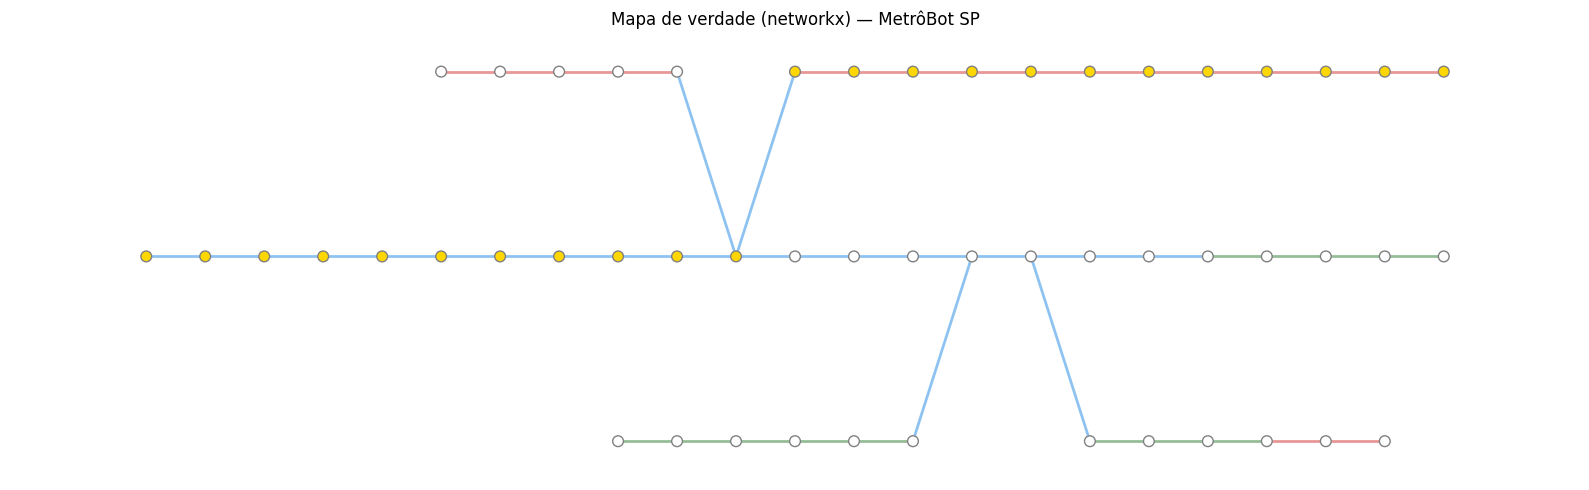

In [ ]:
def desenhar_mapa_networkx(caminho=None):
    if not (TEM_MATPLOTLIB and TEM_NETWORKX):
        print("networkx/matplotlib indisponível — pulando bônus do mapa com networkx.")
        return
    G = nx.Graph()
    edge_colors = []
    for (a, b), linhas_set in LINHAS_DO_TRECHO.items():
        if G.has_edge(a, b):
            continue
        G.add_edge(a, b)
        cor = CORES[sorted(linhas_set)[0]]
        edge_colors.append(cor)
    pos = {e: _POSICOES[e] for e in G.nodes}
    plt.figure(figsize=(16, 5))
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2, alpha=0.5)
    caminho_set = set(caminho or [])
    node_colors = ["gold" if n in caminho_set else "white" for n in G.nodes]
    nx.draw_networkx_nodes(G, pos, node_size=60, node_color=node_colors, edgecolors="gray")
    plt.title("Mapa de verdade (networkx) — MetrôBot SP")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

desenhar_mapa_networkx(bfs(GRAFO, "Tucuruvi", "Corinthians-Itaquera")[0])


## ⭐ Bônus 1 e 2 — Menos baldeações & tempo real simulado (Dijkstra)

In [ ]:
def bfs_menos_baldeacoes(grafo, linhas_do_trecho, origem, destino, bloqueadas=None):
    """Bônus 1: minimiza (baldeacoes, paradas), nessa ordem de prioridade.
    Estado da busca = (estacao, linha_atual)."""
    bloqueadas = bloqueadas or set()
    if origem in bloqueadas or destino in bloqueadas:
        return None
    inicio = (origem, None)
    heap = [((0, 0), [origem], inicio)]
    melhor = {inicio: (0, 0)}
    while heap:
        custo, caminho, estado = heapq.heappop(heap)
        estacao, linha_atual = estado
        if custo > melhor.get(estado, (float("inf"), float("inf"))):
            continue
        if estacao == destino:
            return caminho, custo
        for viz in grafo.get(estacao, []):
            if viz in bloqueadas:
                continue
            linhas_possiveis = linhas_do_trecho.get((estacao, viz), set()) or {None}
            for l in linhas_possiveis:
                baldeou = 1 if (linha_atual is not None and l != linha_atual) else 0
                novo_custo = (custo[0] + baldeou, custo[1] + 1)
                novo_estado = (viz, l)
                if novo_custo < melhor.get(novo_estado, (float("inf"), float("inf"))):
                    melhor[novo_estado] = novo_custo
                    heapq.heappush(heap, (novo_custo, caminho + [viz], novo_estado))
    return None


def dijkstra_tempo(grafo, linhas_do_trecho, origem, destino, bloqueadas=None,
                    min_por_trecho=2, min_por_baldeacao=5):
    """Bônus 2: rota mais rápida considerando tempo por trecho + penalidade por baldeação."""
    bloqueadas = bloqueadas or set()
    if origem in bloqueadas or destino in bloqueadas:
        return None
    inicio = (origem, None)
    heap = [(0, [origem], inicio)]
    melhor = {inicio: 0}
    while heap:
        tempo, caminho, estado = heapq.heappop(heap)
        estacao, linha_atual = estado
        if tempo > melhor.get(estado, float("inf")):
            continue
        if estacao == destino:
            return caminho, tempo
        for viz in grafo.get(estacao, []):
            if viz in bloqueadas:
                continue
            linhas_possiveis = linhas_do_trecho.get((estacao, viz), set()) or {None}
            for escolha in linhas_possiveis:
                baldeou = 1 if (linha_atual is not None and escolha != linha_atual) else 0
                novo_tempo = tempo + min_por_trecho + (min_por_baldeacao if baldeou else 0)
                novo_estado = (viz, escolha)
                if novo_tempo < melhor.get(novo_estado, float("inf")):
                    melhor[novo_estado] = novo_tempo
                    heapq.heappush(heap, (novo_tempo, caminho + [viz], novo_estado))
    return None


_r1 = bfs_menos_baldeacoes(GRAFO, LINHAS_DO_TRECHO, "Palmeiras-Barra Funda", "Vila Prudente")
print("Bônus 1 (menos baldeações):", _r1[1], "| paradas:", len(_r1[0]) - 1)

_r2 = dijkstra_tempo(GRAFO, LINHAS_DO_TRECHO, "Tucuruvi", "Corinthians-Itaquera")
print("Bônus 2 (tempo estimado, min):", _r2[1], "| paradas:", len(_r2[0]) - 1)


Bônus 1 (menos baldeações): (2, 16) | paradas: 16
Bônus 2 (tempo estimado, min): 49 | paradas: 22


## ⭐ Bônus 3 — Linha paralisada (regra lógica)

Usa a regra **R4** do motor de inferência: `linha_paralisada(l) ∧ pertence(e,l) → indisponivel(e)`.
Quando uma linha inteira é "paralisada" (ex.: greve simulada), todas as suas estações somem do grafo
utilizável — sem precisar bloquear estação por estação manualmente.

In [ ]:
def estacoes_indisponiveis_por_linha_paralisada(linhas_paralisadas, linhas=LINHAS):
    fatos0 = fatos_base(linhas, linhas_paralisadas=set(linhas_paralisadas))
    fatos_final, disparadas = encadear_para_frente(fatos0, linhas)
    indisponiveis = {f[1] for f in fatos_final if f[0] == "indisponivel"}
    return indisponiveis, disparadas


_indisp, _disp = estacoes_indisponiveis_por_linha_paralisada({"Linha 3-Vermelha"})
print(f"Linha 3-Vermelha paralisada ⇒ {len(_indisp)} estações indisponíveis.")
_c3, _ = bfs(GRAFO, "Tucuruvi", "Vila Prudente", bloqueadas=_indisp)
print("Ainda dá pra ir de Tucuruvi a Vila Prudente?", "Sim" if _c3 else "Não", "(usando só L1/L2)")


Linha 3-Vermelha paralisada ⇒ 18 estações indisponíveis.
Ainda dá pra ir de Tucuruvi a Vila Prudente? Não (usando só L1/L2)


## 🧮 R6 — Testes automatizados

Os **6 casos obrigatórios** do desafio + casos extras do grupo.

In [ ]:
def rodar_testes():
    total = 0

    # ---- Casos obrigatórios (BFS, 1 parada = 1 trecho) ----
    c1, _ = bfs(GRAFO, "Tucuruvi", "Corinthians-Itaquera")
    nb1, _ = contar_baldeacoes(c1, LINHAS_DO_TRECHO)
    assert len(c1) - 1 == 22, f"Caso 1: esperado 22 paradas, obtido {len(c1)-1}"
    assert nb1 == 1, f"Caso 1: esperado 1 baldeação, obtido {nb1}"
    total += 1

    c2, _ = bfs(GRAFO, "Vila Madalena", "Jabaquara")
    nb2, locais2 = contar_baldeacoes(c2, LINHAS_DO_TRECHO)
    assert len(c2) - 1 == 14, f"Caso 2: esperado 14 paradas, obtido {len(c2)-1}"
    assert nb2 == 1 and locais2[0][0] in ("Paraíso", "Ana Rosa"), f"Caso 2: baldeação inesperada {locais2}"
    total += 1

    c3, _ = bfs(GRAFO, "Palmeiras-Barra Funda", "Vila Prudente")
    nb3, _ = contar_baldeacoes(c3, LINHAS_DO_TRECHO)
    assert len(c3) - 1 == 16, f"Caso 3: esperado 16 paradas, obtido {len(c3)-1}"
    assert nb3 == 2, f"Caso 3: esperado 2 baldeações, obtido {nb3}"
    total += 1

    c4, _ = bfs(GRAFO, "Tucuruvi", "Brás", bloqueadas={"Sé"})
    assert c4 is None, "Caso 4: deveria ser SEM ROTA (Sé fechada)"
    total += 1

    c5, _ = bfs(GRAFO, "Vila Madalena", "Jabaquara", bloqueadas={"Paraíso"})
    assert c5 is None, "Caso 5: deveria ser SEM ROTA (Paraíso fechada corta a L2)"
    total += 1

    c6, _ = bfs(GRAFO, "Vila Prudente", "Jabaquara", bloqueadas={"Paraíso"})
    nb6, locais6 = contar_baldeacoes(c6, LINHAS_DO_TRECHO)
    assert len(c6) - 1 == 13, f"Caso 6: esperado 13 paradas, obtido {len(c6)-1}"
    assert "Ana Rosa" in [c6[0] for c6 in [(e,) for e in c6]] or "Ana Rosa" in c6, "Caso 6: rota deveria passar pela Ana Rosa"
    total += 1

    # ---- Casos extras do grupo ----
    # Extra 1: R6 deduz sozinha as 3 integrações
    fatos0 = fatos_base(LINHAS)
    fatos_f, _ = encadear_para_frente(fatos0, LINHAS)
    integracoes = {f[1] for f in fatos_f if f[0] == "integracao"}
    assert integracoes == {"Sé", "Paraíso", "Ana Rosa"}, f"R6 deveria deduzir 3 integrações, obteve {integracoes}"
    total += 1

    # Extra 2: grafo tem 52 estações e nenhum vizinho duplicado
    assert len(GRAFO) == 52
    assert all(len(v) == len(set(v)) for v in GRAFO.values()), "Há vizinhos duplicados no grafo!"
    total += 1

    # Extra 3: bônus 1 nunca é pior (em baldeações) que a BFS simples
    b1 = bfs_menos_baldeacoes(GRAFO, LINHAS_DO_TRECHO, "Palmeiras-Barra Funda", "Vila Prudente")
    assert b1[1][0] <= nb3, "Bônus 1 (menos baldeações) não pode ter mais baldeações que a BFS simples"
    total += 1

    # Extra 4: linha paralisada torna suas estações indisponíveis via regra lógica
    indisp, _ = estacoes_indisponiveis_por_linha_paralisada({"Linha 2-Verde"})
    assert "Vila Madalena" in indisp and "Sumaré" in indisp
    total += 1

    # Extra 5: R7 - integração com elevador em manutenção precisa de reparo prioritário
    fatos_r7 = fatos_base(LINHAS, elevadores_manutencao={"Sé"})
    fatos_r7_final, _ = encadear_para_frente(fatos_r7, LINHAS)
    assert ("prioridade_reparo", "Sé") in fatos_r7_final, "R7 deveria deduzir 'prioridade_reparo' para 'Sé'"
    total += 1

    print(f"✅ Todos os {total} testes passaram! (mínimo exigido: 8)")
    return total


_n = rodar_testes()
assert _n >= 8

✅ Todos os 11 testes passaram! (mínimo exigido: 8)


## 🖥️ R5 — Interface com `ipywidgets`

Pedido em linguagem natural + botão "Interpretar", campos de origem/destino, acessibilidade, estações
fechadas, elevadores em manutenção, escolha do algoritmo (BFS/DFS/menos baldeações), desenho das 3
linhas destacando rota/visitadas/bloqueadas e o resumo (paradas, baldeações, tempo estimado, regras
disparadas).

In [ ]:
def montar_painel():
    if not TEM_WIDGETS:
        print("ipywidgets indisponível neste ambiente — use as funções diretamente, ex.:")
        print('  planejar("Tucuruvi", "Corinthians-Itaquera")')
        return

    txt_pedido = widgets.Text(placeholder="Ex.: Quero ir do MASP até o Corinthians-Itaquera, sou cadeirante",
                               layout=widgets.Layout(width="480px"))
    btn_interpretar = widgets.Button(description="🤖 Interpretar", button_style="info")

    dd_origem = widgets.Dropdown(options=TODAS_ESTACOES, description="Origem:", value="Tucuruvi")
    dd_destino = widgets.Dropdown(options=TODAS_ESTACOES, description="Destino:", value="Jabaquara")
    chk_acess = widgets.Checkbox(value=False, description="Precisa de acessibilidade")
    sm_fechadas = widgets.SelectMultiple(options=TODAS_ESTACOES, description="Fechadas:",
                                          layout=widgets.Layout(height="90px"))
    sm_elevador = widgets.SelectMultiple(options=TODAS_ESTACOES, description="Elevador em manut.:",
                                          layout=widgets.Layout(height="90px"))
    rb_algo = widgets.RadioButtons(options=[("BFS", "bfs"), ("DFS", "dfs"), ("Menos baldeações (bônus)", "menos")],
                                    description="Algoritmo:")
    chk_pico = widgets.Checkbox(value=False, description="Horário de pico")
    sm_paralisada = widgets.SelectMultiple(options=list(LINHAS.keys()), description="Linha paralisada:",
                                            layout=widgets.Layout(height="60px"))
    btn_planejar = widgets.Button(description="🚇 Planejar rota", button_style="success")
    saida = widgets.Output()

    def ao_interpretar(_):
        with saida:
            clear_output()
            pedido = interpretar_pedido(txt_pedido.value)
            print("Interpretado:", pedido)
            if pedido["origem"] in TODAS_ESTACOES:
                dd_origem.value = pedido["origem"]
            if pedido["destino"] in TODAS_ESTACOES:
                dd_destino.value = pedido["destino"]
            chk_acess.value = pedido["acessibilidade"]
            rb_algo.value = pedido["algoritmo"] if pedido["algoritmo"] in ("bfs", "dfs") else "bfs"

    def ao_planejar(_):
        with saida:
            clear_output()
            origem, destino = dd_origem.value, dd_destino.value
            bloqueadas = set(sm_fechadas.value)
            elevadores = set(sm_elevador.value)

            fatos0 = fatos_base(LINHAS, estacoes_bloqueadas=bloqueadas, elevadores_manutencao=elevadores,
                                 precisa_acessibilidade=chk_acess.value, horario_pico=chk_pico.value,
                                 linhas_paralisadas=set(sm_paralisada.value))
            fatos_final, disparadas = encadear_para_frente(fatos0, LINHAS)
            bloqueadas_efetivas = bloqueadas | {f[1] for f in fatos_final if f[0] == "indisponivel"}

            algo = rb_algo.value
            if algo == "bfs":
                caminho, visitadas = bfs(GRAFO, origem, destino, bloqueadas_efetivas)
                custo_extra = None
            elif algo == "dfs":
                caminho, visitadas = dfs(GRAFO, origem, destino, bloqueadas_efetivas)
                custo_extra = None
            else:
                res = bfs_menos_baldeacoes(GRAFO, LINHAS_DO_TRECHO, origem, destino, bloqueadas_efetivas)
                caminho, visitadas = (res[0], []) if res else (None, [])
                custo_extra = res[1] if res else None

            nb, baldeacoes_info = contar_baldeacoes(caminho, LINHAS_DO_TRECHO) if caminho else (0, [])
            texto_narrado = narrar(origem, destino, caminho, baldeacoes_info, disparadas, algo)

            print(texto_narrado)
            print()
            if caminho:
                tempo_estimado = 2 * (len(caminho) - 1) + 5 * nb
                print(f"📍 Paradas: {len(caminho)-1} | 🔀 Baldeações: {nb} | ⏱️ Tempo estimado: {tempo_estimado} min")
                if baldeacoes_info:
                    print("   Onde trocar:", ", ".join(f"{e} → {l}" for e, l in baldeacoes_info))
            print(f"⚙️ Regras do motor de inferência disparadas: {len(disparadas)}")
            for d in disparadas:
                print("   -", d)
            desenhar_mapa(caminho, visitadas, bloqueadas_efetivas,
                          titulo=f"{origem} → {destino} ({algo.upper()})")

    btn_interpretar.on_click(ao_interpretar)
    btn_planejar.on_click(ao_planejar)

    painel = widgets.VBox([
        widgets.HTML("<h3>🚇 MetrôBot SP 2.0</h3>"),
        widgets.HBox([txt_pedido, btn_interpretar]),
        widgets.HBox([dd_origem, dd_destino]),
        widgets.HBox([chk_acess, chk_pico]),
        widgets.HBox([sm_fechadas, sm_elevador]),
        rb_algo,
        sm_paralisada,
        btn_planejar,
        saida,
    ])
    display(painel)


montar_painel()


## 🌟 Bônus 5 — Relatório de esforço (BFS × DFS em 10 viagens aleatórias)

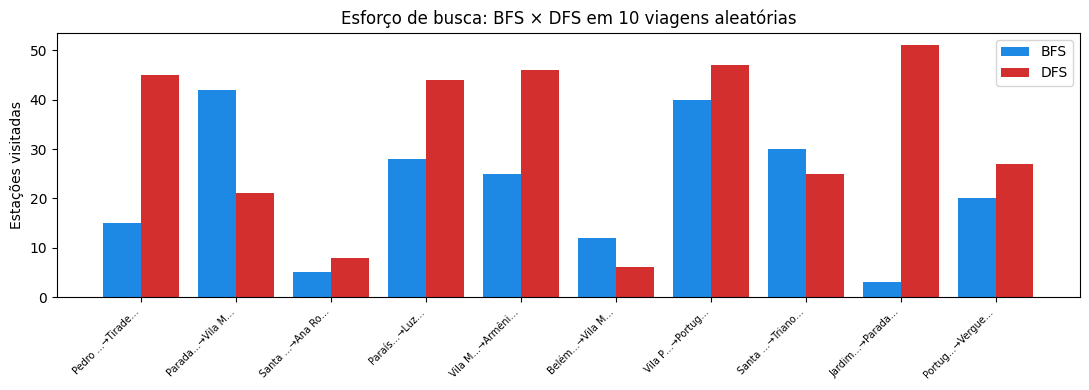

In [ ]:
import random

def relatorio_esforco(n=10, seed=42):
    random.seed(seed)
    estacoes = list(GRAFO.keys())
    pares = []
    while len(pares) < n:
        a, b = random.sample(estacoes, 2)
        if a != b:
            pares.append((a, b))

    visitas_bfs, visitas_dfs = [], []
    for a, b in pares:
        _, vb = bfs(GRAFO, a, b)
        _, vd = dfs(GRAFO, a, b)
        visitas_bfs.append(len(vb))
        visitas_dfs.append(len(vd))

    if not TEM_MATPLOTLIB:
        for i, (a, b) in enumerate(pares):
            print(f"{a} → {b}: BFS visitou {visitas_bfs[i]} | DFS visitou {visitas_dfs[i]}")
        return

    x = range(n)
    plt.figure(figsize=(11, 4))
    plt.bar([i - 0.2 for i in x], visitas_bfs, width=0.4, label="BFS", color="#1e88e5")
    plt.bar([i + 0.2 for i in x], visitas_dfs, width=0.4, label="DFS", color="#d32f2f")
    plt.xticks(list(x), [f"{a[:6]}…→{b[:6]}…" for a, b in pares], rotation=45, ha="right", fontsize=7)
    plt.ylabel("Estações visitadas")
    plt.title("Esforço de busca: BFS × DFS em 10 viagens aleatórias")
    plt.legend()
    plt.tight_layout()
    plt.show()

relatorio_esforco()


## 🤔 Para pensar: por que o caso 5 não tem rota, mas o caso 6 tem?

**Caso 5** — Vila Madalena → Jabaquara, com **Paraíso fechada**: a Linha 2-Verde só se conecta à
Linha 1-Azul em dois pontos, **Paraíso** e **Ana Rosa**. Só que, no trecho da Linha 2, a sequência é
`... Brigadeiro → Paraíso → Ana Rosa → Chácara Klabin ...`. Com Paraíso fechada, a única forma de sair
de Vila Madalena e alcançar Ana Rosa *pela Linha 2* seria passar por Paraíso — que está bloqueada. A
Linha 2 fica "cortada" ao meio: de um lado ficam Vila Madalena...Paraíso(fechada), do outro
Ana Rosa...Vila Prudente, e **Vila Madalena não tem nenhum outro caminho** até esse segundo pedaço.
Por isso: **sem rota**.

**Caso 6** — Vila Prudente → Jabaquara, também com **Paraíso fechada**: aqui a origem (Vila Prudente)
já está do lado de Ana Rosa na Linha 2 (`Ana Rosa → Chácara Klabin → ... → Vila Prudente`), então o
passageiro nunca precisa passar por Paraíso — ele vai direto até **Ana Rosa** pela Linha 2, faz a
baldeação lá para a Linha 1-Azul, e segue até Jabaquara. Como a estação bloqueada não está no
caminho necessário, existe **desvio**, e a viagem acontece normalmente (13 paradas).

Ou seja: a mesma estação fechada pode ou não impedir uma viagem — depende de **qual lado do "corte"**
a origem e o destino estão.